# Ejercicio 4: Modelo Probabilístico

## Objetivo de la práctica
- Comprender los componentes del modelo vectorial mediante cálculos manuales y observación directa.
- Aplicar el modelo de espacio vectorial con TF-IDF para recuperar documentos relevantes.
- Comparar la recuperación con BM25 frente a TF-IDF.
- Analizar visualmente las diferencias entre los modelos.
- Evaluar si los rankings generados son consistentes con lo que considerarías documentos relevantes.

## Parte 0: Carga del Corpus

Se utiliza el corpus `Gutenberg 1000`. Cada archivo `.txt` del directorio representa un documento.

In [3]:
import os
import math

# ------------------------------------------------------------
# El estudiante debe colocar la ruta donde están los archivos
# .txt del corpus Gutenberg 1000
# ------------------------------------------------------------
ruta_directorio = "../data/gutenberg/1000"  

# Se leen todos los archivos .txt del directorio
# Cada archivo es un documento del corpus
archivos = sorted([f for f in os.listdir(ruta_directorio) if f.endswith(".txt")])

# Se carga el contenido de cada documento en una lista
# corpus[i] contiene el texto completo del documento i
corpus = []
for nombre in archivos:
    ruta_completa = os.path.join(ruta_directorio, nombre)
    with open(ruta_completa, "r", encoding="utf-8", errors="ignore") as archivo:
        corpus.append(archivo.read())

# Número total de documentos en la colección
N = len(corpus)
print(f"Documentos cargados: {N}")
print("Ejemplo (primeros 200 caracteres del doc 0):")
print(corpus[0][:200])

Documentos cargados: 1000
Ejemplo (primeros 200 caracteres del doc 0):
﻿The Project Gutenberg eBook of The Declaration of Independence of the United States of America
    
This eBook is for the use of anyone anywhere in the United States and
most other parts of the world


## Parte 1: Cálculo de TF, DF, IDF y TF-IDF

### Actividad 
1. Construye la matriz de términos (TF), y calcula la frecuencia de documentos (DF)
2. Calcula TF-IDF utilizando las fórmulas del curso (sin sklearn).
3. Visualiza los valores en un DataFrame para analizar las diferencias entre los términos.

---
**Fórmulas usadas:**

- **TF(t, d)** = número de veces que el término `t` aparece en el documento `d`
- **DF(t)** = número de documentos que contienen el término `t`
- **IDF(t)** = log( N / DF(t) )  ← forma básica del PDF (slide 5)
- **TF-IDF(t, d)** = TF(t, d) × IDF(t)

In [4]:
# Paso 1: Tokenización 
import string
import os

libros_tokenizados = []  # Lista de listas de palabras

print("Limpiando y tokenizando los 1000 libros...")

for nombre_archivo in archivos:
    ruta_completa = os.path.join(ruta_directorio, nombre_archivo)
    with open(ruta_completa, "r", encoding="utf-8", errors="ignore") as archivo:
        texto = archivo.read() 

        inicio = texto.find("*** START OF")
        fin = texto.find("*** END OF")

        if inicio != -1:
            fin_linea_inicio = texto.find("\n", inicio) 
            texto = texto[fin_linea_inicio:]
        
        if fin != -1:
            texto = texto[:fin]

        texto = texto.lower()

        for signo in string.punctuation:
            texto = texto.replace(signo, ' ')

        palabras = texto.split()
        libros_tokenizados.append(palabras)

cantidad_libros = len(libros_tokenizados)  # N en la fórmula IDF
print(f"Libros tokenizados limpios: {cantidad_libros}")

Limpiando y tokenizando los 1000 libros...
Libros tokenizados limpios: 1000


In [5]:
# Paso 2: Cálculo de TF (Term Frequency) para cada documento
from collections import Counter

tf_por_doc = []

for palabras_del_libro in libros_tokenizados:
    fila_tf = []
    total_palabras_en_libro = len(palabras_del_libro)

    conteo_palabras_libro = Counter(palabras_del_libro)

    for palabra, cantidad_apariciones in conteo_palabras_libro.items():
        tf = cantidad_apariciones / total_palabras_en_libro
        fila_tf.append((palabra, round(tf, 6)))

    tf_por_doc.append(fila_tf)

print(f"Total de documentos procesados y guardados: {len(tf_por_doc)}")

Total de documentos procesados y guardados: 1000


In [6]:
for i, documento in enumerate(tf_por_doc[:10]):
    print(f"Documento {i+1}:", documento)

Documento 1: [('the', 0.064601), ('united', 0.004727), ('states', 0.007353), ('declaration', 0.004202), ('of', 0.058298), ('independence', 0.002626), ('was', 0.002101), ('first', 0.001576), ('e', 0.000525), ('text', 0.002101), ('released', 0.000525), ('by', 0.009454), ('project', 0.004202), ('gutenberg', 0.003151), ('early', 0.000525), ('in', 0.019433), ('1971', 0.00105), ('title', 0.000525), ('stored', 0.000525), ('an', 0.003676), ('emailed', 0.000525), ('instruction', 0.000525), ('set', 0.00105), ('which', 0.007878), ('required', 0.000525), ('a', 0.013655), ('tape', 0.001576), ('or', 0.002101), ('diskpack', 0.000525), ('be', 0.006828), ('hand', 0.000525), ('mounted', 0.000525), ('for', 0.018908), ('retrieval', 0.000525), ('disk', 0.000525), ('pack', 0.000525), ('size', 0.000525), ('large', 0.002626), ('cake', 0.00105), ('carrier', 0.000525), ('cost', 0.000525), ('1500', 0.000525), ('and', 0.035189), ('contained', 0.001576), ('5', 0.000525), ('megabytes', 0.000525), ('this', 0.006828)

In [7]:
# Paso 3: Vocabulario 
# Se construye el vocabulario con todos los términos únicos del corpus
vocabulario = sorted(set(token for tokens in libros_tokenizados for token in tokens))
print(f"Tamaño del vocabulario: {len(vocabulario)} términos")

Tamaño del vocabulario: 1212189 términos


In [8]:
# Paso 4: Cálculo de DF (Document Frequency) para cada término del vocabulario
df = {}

# preparar el diccionario poniendo todos los términos en 0
for termino in vocabulario:
    df[termino] = 0

for fila_tf in tf_por_doc:
    # Recorrer las palabras de ese documento
    for palabra, valor_tf in fila_tf:
        # Si la palabra pertenece alvocabulario, sumar1
        if palabra in df:
            df[palabra] += 1

In [9]:
# Paso 5: Cálculo de IDF (Inverse Document Frequency) para cada término del vocabulario
N = len(tf_por_doc) # Número total de documentos
idf = {}

for termino, frecuencia in df.items():
    # La fórmula es: log10(Total_Documentos / Documentos_que_contienen_el_termino)
    idf[termino] = math.log10(N / frecuencia)

In [10]:
tfidf_matriz = []

print("Calculando TF-IDF para cada libro (formato disperso)...")

for fila_tf in tf_por_doc:
    tfidf_del_libro = {}  # Diccionario disperso, solo guarda palabras presentes

    for palabra, tf in fila_tf:
        
        if palabra in idf:
            # TF-IDF: multiplicar TF por el IDF precalculado
            valor_tfidf = tf * idf[palabra]

            if valor_tfidf > 0:
                tfidf_del_libro[palabra] = round(valor_tfidf, 6)

    tfidf_matriz.append(tfidf_del_libro)

print(f"Matriz TF-IDF dispersa calculada. Total de documentos: {len(tfidf_matriz)}")

n_filas = len(tfidf_matriz)
m_columnas = len(idf)

print(f"La dimensión de la matriz TF-IDF es: {n_filas} x {m_columnas}")

Calculando TF-IDF para cada libro (formato disperso)...
Matriz TF-IDF dispersa calculada. Total de documentos: 1000
La dimensión de la matriz TF-IDF es: 1000 x 1212189


In [11]:

# Visualizar los TF-IDF de los primeros 3 documentos (solo las primeras 5 palabras del vocabulario para no saturar la salida)
print("Mostrando los TF-IDF de los primeros 3 documentos (solo las primeras 5 palabras del vocabulario):")
for i, fila in enumerate(tfidf_matriz[:3]):
    print(f"Doc {i+1}:", dict(list(fila.items())[:5]))

Mostrando los TF-IDF de los primeros 3 documentos (solo las primeras 5 palabras del vocabulario):
Doc 1: {'united': 6e-06, 'states': 1e-05, 'declaration': 0.002091, 'independence': 0.001268, 'was': 5.5e-05}
Doc 2: {'old': 1e-06, 'testament': 1.4e-05, 'king': 0.000385, 'james': 2.1e-05, 'version': 2e-06}
Doc 3: {'complete': 3e-06, 'works': 0.0, 'william': 3.2e-05, 'shakespeare': 3e-06, 'contents': 9e-06}


## Parte 2: Ranking de documentos usando TF-IDF

### Actividad 

1. Dada una consulta, construye el vector de consulta
2. Calcula la similitud coseno entre la consulta y cada documento usando los vectores TF-IDF
3. Genera un ranking de los documentos ordenados por relevancia.
4. Muestra los resultados en una tabla.

---
**Similitud coseno:**

$$\text{sim}(q, d) = \frac{\vec{q} \cdot \vec{d}}{|\vec{q}| \cdot |\vec{d}|}$$

Donde cada vector tiene componentes TF-IDF para cada término del vocabulario.

In [12]:
import math
import pandas as pd

c:\Users\Dayana\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [13]:
import re

def tokenizar(texto):
    """
    Convierte el texto a minúsculas y extrae únicamente las palabras,
    eliminando signos de puntuación, comas, puntos, etc.
    """
    texto = texto.lower()
    tokens = re.findall(r'\b\w+\b', texto)
    
    return tokens

In [14]:
# Consulta 

consulta = "castle mystery crimes"

tokens_consulta = tokenizar(consulta)
print(f"Tokens de la consulta: {tokens_consulta}")

# Vector TF-IDF de la consulta 
total_palabras_consulta = len(tokens_consulta)
conteo_consulta = Counter(tokens_consulta)

tfidf_consulta = {}
for t, cantidad in conteo_consulta.items():
    if t in idf: # Solo procesar palabras que existan en vocabulario 
        tf = cantidad / total_palabras_consulta
        tfidf_consulta[t] = tf * idf[t]



Tokens de la consulta: ['castle', 'mystery', 'crimes']


In [15]:
# Función: similitud coseno 
def similitud_coseno(vec_a, vec_b):
    """Calcula la similitud coseno entre dos vectores."""
    producto_punto = sum(vec_a[t] * vec_b.get(t, 0) for t in vec_a)
    
    # Norma de cada vector: raíz de la suma de cuadrados
    norma_a = math.sqrt(sum(v**2 for v in vec_a.values()))
    norma_b = math.sqrt(sum(v**2 for v in vec_b.values()))
    
    # Evita división por cero
    if norma_a == 0 or norma_b == 0:
        return 0.0
    return producto_punto / (norma_a * norma_b)


In [16]:
#  Ranking TF-IDF 
# Se calcula la similitud coseno entre la consulta y cada documento de la matriz
scores_tfidf = []

for i, tfidf_del_libro in enumerate(tfidf_matriz):
    score = similitud_coseno(tfidf_consulta, tfidf_del_libro)
    
    nombre_doc = archivos[i] if 'archivos' in locals() else f"Documento {i+1}"
    scores_tfidf.append((nombre_doc, round(score, 6)))

# Se ordenan los documentos de mayor a menor score
ranking_tfidf = sorted(scores_tfidf, key=lambda x: x[1], reverse=True)

#  Tabla de resultados 
top_k = 10  # número de documentos a mostrar
df_ranking_tfidf = pd.DataFrame(ranking_tfidf[:top_k], columns=["documento", "score_tfidf"])
df_ranking_tfidf.index += 1  # ranking empieza en 1
df_ranking_tfidf.index.name = "posición"

print(f"\nTop {top_k} documentos más relevantes para: '{consulta}'")
print(df_ranking_tfidf)


Top 10 documentos más relevantes para: 'castle mystery crimes'
          documento  score_tfidf
posición                        
1         pg477.txt     0.106799
2         pg699.txt     0.048647
3         pg509.txt     0.047465
4         pg382.txt     0.047377
5         pg369.txt     0.037104
6         pg750.txt     0.037000
7         pg601.txt     0.029366
8         pg640.txt     0.027763
9         pg119.txt     0.026547
10        pg476.txt     0.025741


## Parte 3: Ranking con BM25

### Actividad 

1. Implementa un sistema de recuperación usando el modelo BM25.
2. Usa la misma consulta del ejercicio anterior.
3. Calcula el score BM25 para cada documento y genera un ranking.
4. Compara manualmente con el ranking de TF-IDF.

### Algoritmo BM25 (fórmula del PDF, slide 6):

$$\text{BM25}(d, q) = \sum_{t \in q} \text{IDF}(t) \cdot \frac{(k_1 + 1) \cdot tf_{t,d}}{k_1 \left((1-b) + b \cdot \frac{|d|}{\text{avgdl}}\right) + tf_{t,d}}$$

Donde el IDF usa la corrección de 0.5 del PDF (slide 5):

$$\text{IDF}_{0.5}(t) = \log\frac{N - df_t + 0.5}{df_t + 0.5}$$

Parámetros típicos (slide 9): **k₁ = 1.5**, **b = 0.75**

In [17]:
# ── Paso 1: Longitudes de documentos ─────────────────────────
# longitud_doc[i] = número de tokens del documento i
longitud_doc = [len(tokens) for tokens in libros_tokenizados]

# Longitud promedio de los documentos en la colección
longitud_promedio = sum(longitud_doc) / N
print(f"Longitud promedio de documentos: {longitud_promedio:.1f} tokens")

# IDF_0.5(t) = log( (N - df(t) + 0.5) / (df(t) + 0.5) )
# Se aplica un piso de 0 si el valor fuera negativo (términos muy comunes)
idf_bm25 = {}
for termino in vocabulario:
    df_t = df[termino]
    valor = math.log((N - df_t + 0.5) / (df_t + 0.5))
    idf_bm25[termino] = max(valor, 0.0)  # piso en 0 (slide 9)

k1 = 1.5   # controla saturación de TF (rango típico: 1.2 – 2.0)
b  = 0.75  # controla normalización por longitud (valor estándar)

def score_bm25_documento(tokens_query, tf_doc, longitud_d, longitud_prom):
    """
    Calcula el score BM25 de un documento para una consulta.

    Parámetros:
        tokens_query  : lista de tokens de la consulta
        tf_doc        : Counter con frecuencias CRUDAS de términos del documento
        longitud_d    : número de tokens del documento
        longitud_prom : longitud promedio de todos los documentos

    Retorna:
        score (float) : suma de contribuciones de cada término de la query
    """
    score = 0.0
    for termino in tokens_query:
        if termino not in idf_bm25:
            continue  # el término no está en el vocabulario
        
        tf_td = tf_doc.get(termino, 0)  # frecuencia CRUDA del término en este documento
        
        # Factor de normalización por longitud del documento
        normalizacion = k1 * ((1 - b) + b * (longitud_d / longitud_prom))
        
        # Componente de saturación de TF (numerador y denominador)
        saturacion_tf = ((k1 + 1) * tf_td) / (normalizacion + tf_td)
        
        # Aporte del término al score total del documento
        score += idf_bm25[termino] * saturacion_tf
    
    return score

# Se calcula el score BM25 de cada documento con la misma consulta
scores_bm25 = []
for i in range(N):
    # BM25 requiere frecuencias CRUDAS (conteos), no normalizadas
    tf_doc = Counter(libros_tokenizados[i])
    score = score_bm25_documento(
        tokens_consulta,
        tf_doc,
        longitud_doc[i],
        longitud_promedio
    )
    scores_bm25.append((archivos[i], round(score, 6)))

# Se ordena de mayor a menor score
ranking_bm25 = sorted(scores_bm25, key=lambda x: x[1], reverse=True)

df_ranking_bm25 = pd.DataFrame(ranking_bm25[:top_k],
                                columns=["documento", "score_bm25"])
df_ranking_bm25.index += 1
df_ranking_bm25.index.name = "posición"

print(f"\nTop {top_k} documentos más relevantes para: '{consulta}' (BM25)")
print(df_ranking_bm25)

print("\n── Comparación Top 10: TF-IDF vs BM25 ──")
comparacion = pd.DataFrame({
    "TF-IDF": [r[0] for r in ranking_tfidf[:top_k]],
    "BM25":   [r[0] for r in ranking_bm25[:top_k]]
}, index=range(1, top_k + 1))
comparacion.index.name = "posición"
print(comparacion)

Longitud promedio de documentos: 86466.0 tokens

Top 10 documentos más relevantes para: 'castle mystery crimes' (BM25)
          documento  score_bm25
posición                       
1         pg601.txt    2.642033
2         pg699.txt    2.499671
3         pg446.txt    2.475687
4         pg696.txt    2.430409
5         pg488.txt    2.318039
6         pg395.txt    2.289920
7         pg204.txt    2.281136
8         pg733.txt    2.259505
9         pg891.txt    2.247378
10        pg511.txt    2.222162

── Comparación Top 10: TF-IDF vs BM25 ──
             TF-IDF       BM25
posición                      
1         pg477.txt  pg601.txt
2         pg699.txt  pg699.txt
3         pg509.txt  pg446.txt
4         pg382.txt  pg696.txt
5         pg369.txt  pg488.txt
6         pg750.txt  pg395.txt
7         pg601.txt  pg204.txt
8         pg640.txt  pg733.txt
9         pg119.txt  pg891.txt
10        pg476.txt  pg511.txt


¿Por qué sale todo 0 en bm25?

## Parte 4: Comparación visual entre TF-IDF y BM25

### Actividad 

1. Utiliza un gráfico de barras para visualizar los scores obtenidos por cada documento según TF-IDF y BM25.
2. Compara los rankings visualmente.
3. ¿Qué documentos obtienen scores más altos en un modelo que en otro?
4. ¿A qué se podría deber esta diferencia?

In [18]:
import matplotlib.pyplot as plt
import matplotlib

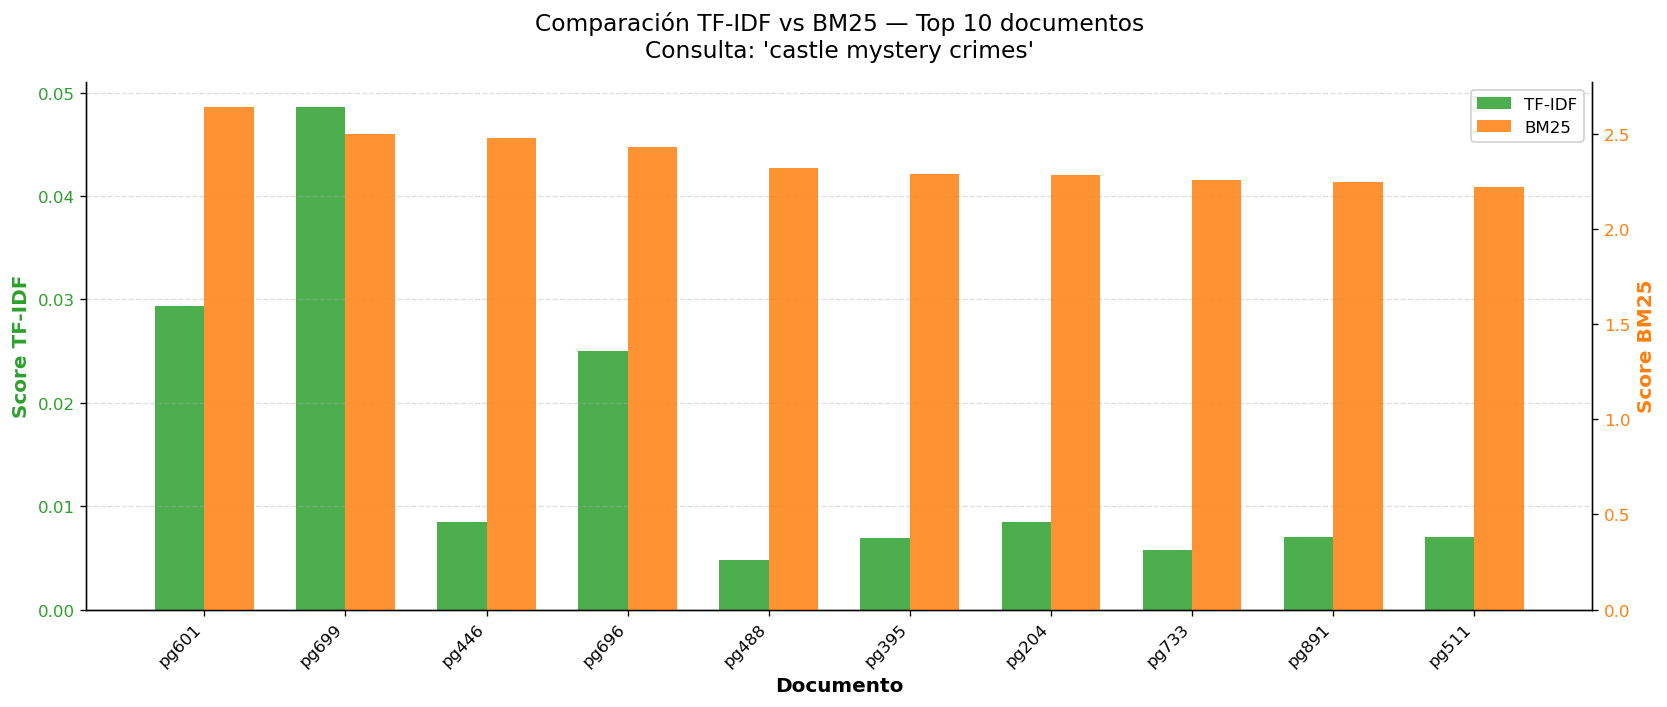

In [22]:
import matplotlib.pyplot as plt
import os

matplotlib.rcParams['figure.dpi'] = 120  

op_k = 10 

top_docs = [nombre for nombre, _ in ranking_bm25[:top_k]]
dict_tfidf = dict(ranking_tfidf)
dict_bm25  = dict(ranking_bm25)

scores_tfidf_top = [dict_tfidf.get(doc, 0) for doc in top_docs]
scores_bm25_top  = [dict_bm25.get(doc,  0) for doc in top_docs]

etiquetas = [os.path.splitext(d)[0][:20] for d in top_docs]

x      = range(top_k)
ancho  = 0.35  

fig, ax1 = plt.subplots(figsize=(14, 6))

color_tfidf = '#2ca02c'  # Verde
color_bm25 = '#ff7f0e'   # Naranja

barras_tfidf = ax1.bar([i - ancho/2 for i in x], scores_tfidf_top,
                       width=ancho, label="TF-IDF", color=color_tfidf, alpha=0.85)

ax1.set_xlabel("Documento", fontsize=12, fontweight='bold')
ax1.set_ylabel("Score TF-IDF", color=color_tfidf, fontsize=12, fontweight='bold')
ax1.tick_params(axis='y', labelcolor=color_tfidf)
ax1.set_xticks(list(x))
ax1.set_xticklabels(etiquetas, rotation=45, ha="right", fontsize=10)

# Agregar grilla horizontal sutil guiada por el eje izquierdo
ax1.grid(axis='y', linestyle='--', alpha=0.4)

# Clonar el eje X para crear un segundo eje Y
ax2 = ax1.twinx()  

barras_bm25 = ax2.bar([i + ancho/2 for i in x], scores_bm25_top,
                      width=ancho, label="BM25", color=color_bm25, alpha=0.85)

ax2.set_ylabel("Score BM25", color=color_bm25, fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=color_bm25)

# --- Título y Leyenda ---
ax1.set_title(f"Comparación TF-IDF vs BM25 — Top {top_k} documentos\nConsulta: '{consulta}'", 
              fontsize=14, pad=15)

# Unificar leyendas de ambos ejes en un solo cuadro
lineas1, labels1 = ax1.get_legend_handles_labels()
lineas2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lineas1 + lineas2, labels1 + labels2, loc='upper right', framealpha=0.9)

# Limpiar bordes innecesarios (Top)
ax1.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)

plt.tight_layout()
plt.show()

**3. ¿Qué documentos obtienen puntajes de mayor peso relativo en un modelo frente al otro?**

Al analizar los resultados, se identifican tres casos principales que presentan discrepancias notables entre ambos modelos:

*   **Documento pg699:** En el modelo TF-IDF, se posiciona como el documento más relevante con una diferencia significativa. Sin embargo, en el modelo BM25 desciende al segundo lugar, mostrando un puntaje que no destaca tan marcadamente sobre el resto.
*   **Documento pg601:** Para el modelo BM25, este documento ocupa el primer lugar en relevancia. En contraste, su valoración bajo TF-IDF es considerablemente menor, alcanzando apenas la mitad del puntaje asignado a pg699 en dicho modelo.
*   **Documento pg446:** Presenta el mayor contraste entre ambas métricas. Mientras que en BM25 mantiene un tercer lugar con un puntaje elevado, en TF-IDF su valoración decae drásticamente, situándose por debajo de documentos de menor relevancia, como el pg204.



**4. ¿A qué se deben estas diferencias?**

Las discrepancias derivan del funcionamiento matemático de cada algoritmo. El modelo BM25 opera como una evolución de TF-IDF, diseñada para mitigar dos limitaciones fundamentales:

**A. Saturación de términos**
*   **En TF-IDF:** Recompensa de manera casi ilimitada la repetición bruta de una palabra dentro de un texto. A mayor frecuencia, mayor puntaje continuo.
*   **En BM25:** Implementa un límite matemático (saturación). El modelo asume que, a partir de cierto umbral de repeticiones, las menciones adicionales de un mismo término no aportan mayor relevancia al documento.
*   **Impacto en los resultados:** Es probable que el documento pg699 repita excesivamente los términos de búsqueda, inflando su puntaje en TF-IDF. Por su parte, BM25 modera este efecto, otorgando la máxima relevancia a pg601, el cual presentaría un uso más equilibrado de los términos clave ("castle", "mystery", "crimes").

**B. Normalización por longitud del documento**
*   **En TF-IDF:** Resulta más vulnerable a la extensión del texto. Los documentos largos poseen una probabilidad estadística mayor de contener los términos de búsqueda por mera aleatoriedad, lo que puede distorsionar la evaluación.
*   **En BM25:** Introduce un factor de penalización para los documentos extensos que presentan baja densidad de los términos buscados. Simultáneamente, favorece a los textos más cortos si presentan dichas palabras, interpretándolo como una alta concentración en el tema de interés.

**Conclusión:**
El comportamiento del documento pg446 sugiere que se trata de un texto extenso, lo cual diluye su puntaje bajo el enfoque tradicional de TF-IDF. No obstante, la densidad real de sus términos de interés es valorada positivamente por el sistema de normalización del modelo BM25.